Episode 0, Total Waiting Time: 1296
Episode 20, Total Waiting Time: 416
Episode 40, Total Waiting Time: 640
Episode 60, Total Waiting Time: 701
Episode 80, Total Waiting Time: 708
Episode 100, Total Waiting Time: 647
Episode 120, Total Waiting Time: 910
Episode 140, Total Waiting Time: 939
Episode 160, Total Waiting Time: 584
Episode 180, Total Waiting Time: 657


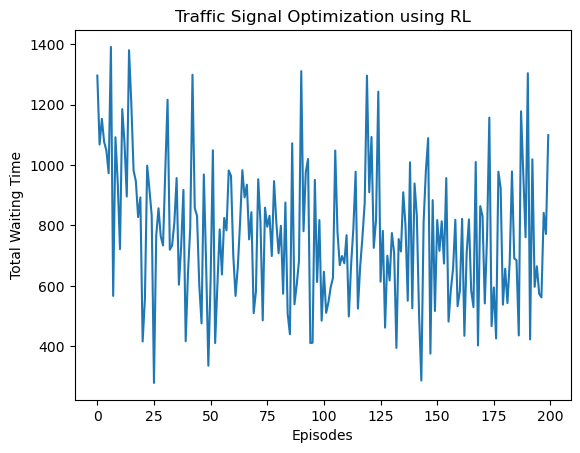

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Parameters
EPISODES = 200
STEPS = 50
ALPHA = 0.1
GAMMA = 0.9
EPSILON = 0.1

# Actions: 0 = NS Green, 1 = EW Green
ACTIONS = [0, 1]

# Q-table
Q = {}

def get_state(queues):
    # Reduce state space (bucket values to avoid explosion)
    return tuple([min(q, 10) for q in queues])

def choose_action(state):
    if random.uniform(0, 1) < EPSILON:
        return random.choice(ACTIONS)
    return np.argmax(Q.get(state, [0, 0]))

def update_q(state, action, reward, next_state):
    Q.setdefault(state, [0, 0])
    Q.setdefault(next_state, [0, 0])
    
    Q[state][action] += ALPHA * (
        reward + GAMMA * max(Q[next_state]) - Q[state][action]
    )

def simulate():
    episode_waiting = []

    for ep in range(EPISODES):
        queues = [0, 0, 0, 0]  # N, S, E, W
        total_wait = 0

        for step in range(STEPS):
            state = get_state(queues)
            action = choose_action(state)

            # Cars arrive randomly
            queues = [q + random.randint(0, 2) for q in queues]

            # Cars pass depending on signal
            if action == 0:  # North-South Green
                queues[0] = max(0, queues[0] - 2)
                queues[1] = max(0, queues[1] - 2)
            else:  # East-West Green
                queues[2] = max(0, queues[2] - 2)
                queues[3] = max(0, queues[3] - 2)

            reward = -sum(queues)
            total_wait += sum(queues)

            next_state = get_state(queues)
            update_q(state, action, reward, next_state)

        episode_waiting.append(total_wait)

        if ep % 20 == 0:
            print(f"Episode {ep}, Total Waiting Time: {total_wait}")

    return episode_waiting

# Run simulation
waiting_times = simulate()

# Plot results
plt.plot(waiting_times)
plt.xlabel("Episodes")
plt.ylabel("Total Waiting Time")
plt.title("Traffic Signal Optimization using RL")
plt.show()